### Euler Forward method with global error estimation step by step

Forward Euler method tries to solve differential equations of the form:

$$
    y'(t) = f(t, y(t))
$$

For each step, the total error (with sign) $E_i$ committed is:

$$
    E_{i + 1} = \left(1 + h \frac{\partial f}{\partial y}(t_i, y_i) \right) E_i - \frac{h^2}{2} \left( \frac{\partial f}{\partial t}(t_i, y_i) + f(t_i, y_i) \frac{\partial f}{\partial y}(t_i, y_i) \right) + \frac{\epsilon_{mach}}{2} \left| y_{i + 1} \right|
$$

This formula is complete: it accounts to local roundoff error, local truncation error and error propagation from previous iterations!

Let's see it in action

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton # For backward method, see later

np.set_printoptions(suppress = True) # Suppress engineering notation

In [2]:
def euler_forward(f, ft, fy, t0, T, h, y0): # Implements basic Euler's forward method with global error tracking each step

    u = 2 ** (- 53) # Roundoff error

    L = T - t0 # Time length
    subdivs = round(L / h) # Number of subdivisions (int)
    ts = np.linspace(t0, T, subdivs + 1) # Time steps array
    h = L / subdivs # h redefined
    
    # Initialization of the solution and errors
    ys = np.empty(subdivs + 1)
    errs = np.empty(subdivs + 1)

    y = y0
    err = 0.0
    ys[0] = y
    errs[0] = err

    for j in range(subdivs): # Loop over subdivisions
        
        t = ts[j]
        y_next = y + h * f(t, y) # Euler forward step

        local_trunc = - h ** 2 / 2.0 * (ft(t, y) + f(t, y) * fy(t, y)) # Local truncation error (with sign)
        local_round = u * abs(y_next) # Local roundoff error (magnitude)
        err = (1.0 + h * fy(t, y)) * err + local_trunc + local_round # Error propagation. It's the total error on y_j (with sign)

        # Updates
        y = y_next
        ys[j + 1] = y
        errs[j + 1] = err

    return ts, ys, np.abs(errs) # Returns time steps, numerical solution, absolute global error

def plot(t, y, y_exact, err_est, title = 'Euler Forward'): # Plotting function

    y_exact = y_exact(t)
    actual_err = np.abs(y - y_exact)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (10, 5))

    # Plot solution
    ax1.plot(t, y, label = r"Approximated $y(t)$", color = 'red')
    ax1.plot(t, y_exact, linestyle = "--", label = "Exact", color = 'black')
    ax1.fill_between(t, y - err_est, y + err_est, color = 'gray', alpha = 0.4, label = r"Error bound $y \pm error$")
    ax1.set_xlabel("t")
    ax1.set_ylabel(r"$y(t)$")
    ax1.set_title(title + " solution")
    ax1.grid(linestyle = '--', color = 'gray', alpha = 0.5)
    ax1.legend(loc = 'best')

    # Plot error tracking
    ax2.semilogy(t, err_est, label = "Estimated cumulative error", color = 'red')
    ax2.semilogy(t, actual_err, label = "Actual absolute error", color = 'blue')
    ax2.set_xlabel("t")
    ax2.set_ylabel("absolute error")
    ax2.set_title("Error tracking")
    ax2.grid(linestyle = '--', color = 'gray', alpha = 0.5)
    ax2.legend(loc = 'best')

    fig.tight_layout()
    plt.show()

def plot2(t, err_est_h, err_est_h2, E_h_Rich): # Plotting function for Richardson comparison
    
    plt.title('Estimation error methods comparison')
    plt.semilogy(t, err_est_h, label = r'Global error $y_{h}(t)$')
    plt.semilogy(t, E_h_Rich, label = r'Rich extrap. $y_{h}(t)$')
    plt.semilogy(t, err_est_h2[::2], label = r'Global error $y_{h / 2}(t)$')
    plt.semilogy(t, E_h_Rich / 2.0, label = r'Rich extrap. $y_{h / 2}(t)$')
    plt.xlabel('t')
    plt.ylabel(r'$E(t)$')
    plt.legend(loc = 'best', frameon = False)
    plt.grid(linestyle = '--', color = 'gray', alpha = 0.3)
    plt.show()

Solve:

$$
    y'(t) = - y(t) \quad y(0) = 1
$$

Compute the errors using local error propagation and Richardson global error estimation, for comparison

In [3]:
def f(t, y): return - y # f(t, y)
def ft(t, y): return 0.0 # Derivative of f(t, y) with respect to t
def fy(t, y): return - 1.0 # Derivative of f(t, y) with respect to y
def y_exact(t): return np.exp(- t) # Exact solution function

y0 = 1.0 # y(0)
t0 = 0.0 # Initial t
T = 3.0 # Final t
h = 0.1 # Fixed step size

In [4]:
t, y, err_est = euler_forward(f, ft, fy, t0, T, h, y0) # Run the function
t, y, err_est # Results

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. ]),
 array([1.        , 0.9       , 0.81      , 0.729     , 0.6561    ,
        0.59049   , 0.531441  , 0.4782969 , 0.43046721, 0.38742049,
        0.34867844, 0.3138106 , 0.28242954, 0.25418658, 0.22876792,
        0.20589113, 0.18530202, 0.16677182, 0.15009464, 0.13508517,
        0.12157665, 0.10941899, 0.09847709, 0.08862938, 0.07976644,
        0.0717898 , 0.06461082, 0.05814974, 0.05233476, 0.04710129,
        0.04239116]),
 array([0.        , 0.005     , 0.009     , 0.01215   , 0.01458   ,
        0.0164025 , 0.0177147 , 0.01860043, 0.01913188, 0.01937102,
        0.01937102, 0.01917731, 0.01882864, 0.01835792, 0.01779306,
        0.01715759, 0.01647129, 0.01575067, 0.01500946, 0.01425899,
        0.01350852, 0.01276555, 0.01203609, 0.01132487, 0.01063553,
        0.00997081, 0.00933267, 0.00872246, 0.008

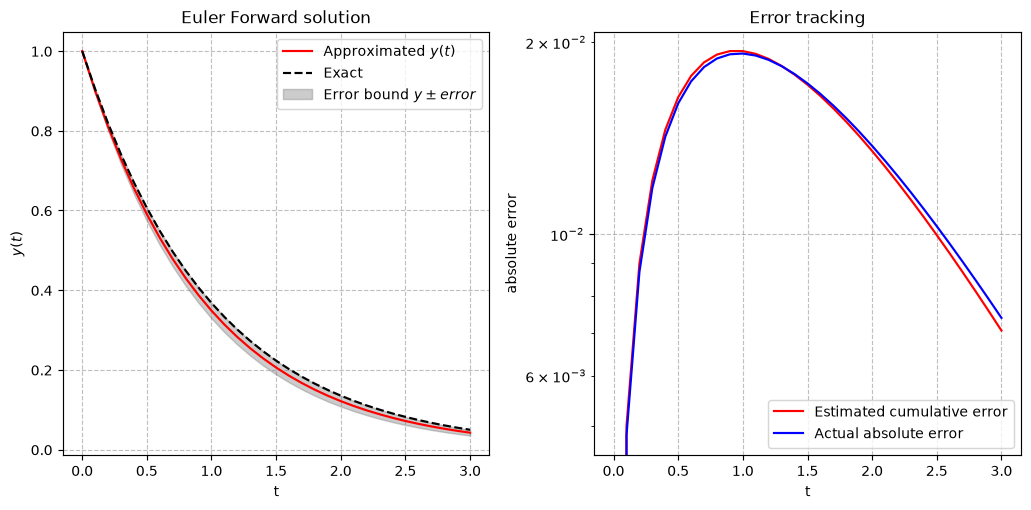

In [5]:
plot(t, y, y_exact, err_est) # Plotting results

Will Richardson method work accordigly? Let's apply:

$$
    E_{h}^{Rich} = 2 | y_{h / 2} - y_{h} |
$$

In [6]:
_, yh, err_est_h = euler_forward(f, ft, fy, t0, T, h, y0) # h = 0.1
_, yh2, err_est_h2 = euler_forward(f, ft, fy, t0, T, h / 2.0, y0) # h = 0.05

E_h_Rich = 2.0 * np.abs(yh2[::2] - yh) # Richardson error estimation of y_h(t)

err_est_h, E_h_Rich

(array([0.        , 0.005     , 0.009     , 0.01215   , 0.01458   ,
        0.0164025 , 0.0177147 , 0.01860043, 0.01913188, 0.01937102,
        0.01937102, 0.01917731, 0.01882864, 0.01835792, 0.01779306,
        0.01715759, 0.01647129, 0.01575067, 0.01500946, 0.01425899,
        0.01350852, 0.01276555, 0.01203609, 0.01132487, 0.01063553,
        0.00997081, 0.00933267, 0.00872246, 0.00814096, 0.00758854,
        0.00706519]),
 array([0.        , 0.005     , 0.0090125 , 0.01218378, 0.01464086,
        0.01649388, 0.01783818, 0.01875616, 0.01931892, 0.01958766,
        0.01961496, 0.0194459 , 0.01911898, 0.01866702, 0.01811792,
        0.01749526, 0.01681893, 0.0161056 , 0.01536916, 0.01462114,
        0.013871  , 0.01312646, 0.01239373, 0.01167773, 0.01098229,
        0.01031035, 0.00966404, 0.00904485, 0.00845373, 0.00789116,
        0.00735728]))

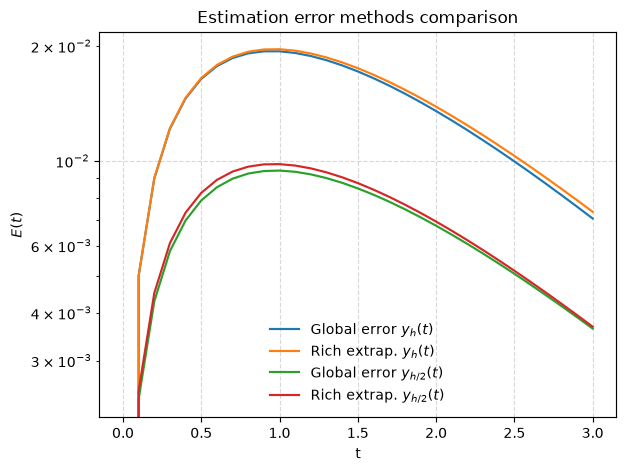

In [7]:
plot2(t, err_est_h, err_est_h2, E_h_Rich) # Plotting comparison

Richardson estimation is very good! Let's try with another differential equation:

$$
    y'(t) = - t \, y(t)^2 \quad y(0) = 1
$$

In [8]:
def f(t, y): return - y ** 2 * t # f(t, y)
def ft(t, y): return - y ** 2 # Derivative of f(t, y) with respect to t
def fy(t, y): return - 2.0 * y * t # Derivative of f(t, y) with respect to y
def y_exact(t): return 2.0 / (2.0 + t ** 2) # Exact solution function

y0 = 1.0 # y(0)
t0 = 0.0 # Initial t
T = 3.0 # Final t
h = 0.1 # Fixed step size

In [9]:
t, y, err_est = euler_forward(f, ft, fy, t0, T, h, y0) # Solution
t, y, err_est

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. ]),
 array([1.        , 1.        , 0.99      , 0.970398  , 0.94214783,
        0.90664213, 0.86554213, 0.82059234, 0.77345632, 0.72559754,
        0.67821328, 0.63221596, 0.58824928, 0.54672482, 0.50786677,
        0.47175676, 0.4383736 , 0.40762617, 0.37937912, 0.35347199,
        0.32973293, 0.30798816, 0.28806826, 0.26981193, 0.25306828,
        0.23769782, 0.22357276, 0.21057672, 0.19860423, 0.18756001,
        0.17735817]),
 array([0.        , 0.005     , 0.0098    , 0.0139243 , 0.01699952,
        0.01881838, 0.01935908, 0.01875981, 0.01726392, 0.0151573 ,
        0.01271573, 0.0101712 , 0.00769739, 0.00540965, 0.00337341,
        0.00161588, 0.00013765, 0.00107742, 0.00205472, 0.00282361,
        0.00341394, 0.00385404, 0.00416958, 0.00438317, 0.00451422,
        0.00457919, 0.00459183, 0.00456352, 0.004

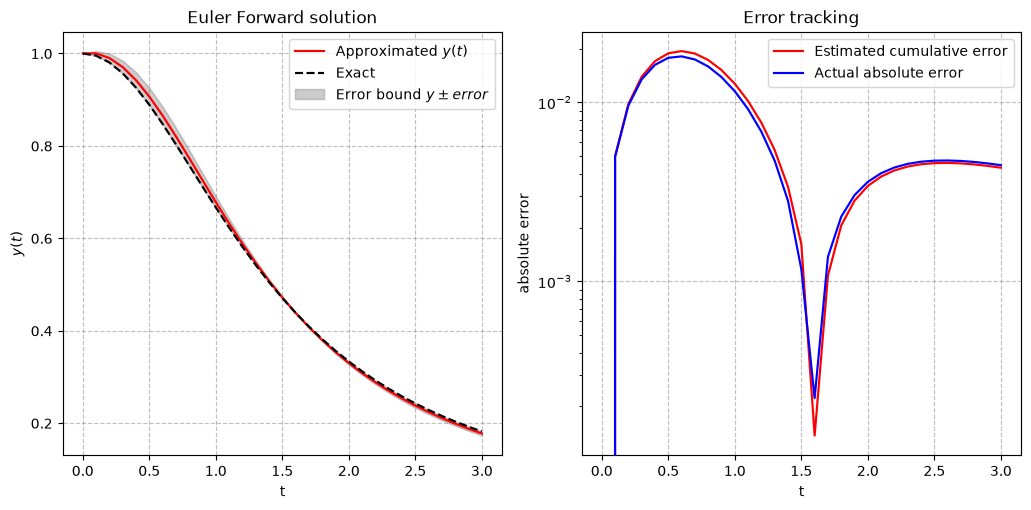

In [10]:
plot(t, y, y_exact, err_est) # Plotting results

Let's check again whether Richardson's global error estimation works

In [11]:
_, yh, err_est_h = euler_forward(f, ft, fy, t0, T, h, y0) # Solution for h = 0.1
_, yh2, err_est_h2 = euler_forward(f, ft, fy, t0, T, h / 2.0, y0) # Solution for h = 0.05

E_h_Rich = 2.0 * np.abs(yh - yh2[::2]) # Richardson error estimation of y_h(t)
err_est_h, E_h_Rich

(array([0.        , 0.005     , 0.0098    , 0.0139243 , 0.01699952,
        0.01881838, 0.01935908, 0.01875981, 0.01726392, 0.0151573 ,
        0.01271573, 0.0101712 , 0.00769739, 0.00540965, 0.00337341,
        0.00161588, 0.00013765, 0.00107742, 0.00205472, 0.00282361,
        0.00341394, 0.00385404, 0.00416958, 0.00438317, 0.00451422,
        0.00457919, 0.00459183, 0.00456352, 0.00450359, 0.00441965,
        0.00431787]),
 array([0.        , 0.005     , 0.00972665, 0.01371921, 0.01663279,
        0.01829276, 0.01870436, 0.01802107, 0.01648887, 0.0143867 ,
        0.01197867, 0.00948449, 0.00706761, 0.00483622, 0.00285155,
        0.00113894, 0.00030131, 0.00148477, 0.00243584, 0.00318278,
        0.00375445, 0.00417833, 0.00447943, 0.00467983, 0.0047986 ,
        0.00485195, 0.00485346, 0.0048144 , 0.00474406, 0.00465   ,
        0.0045384 ]))

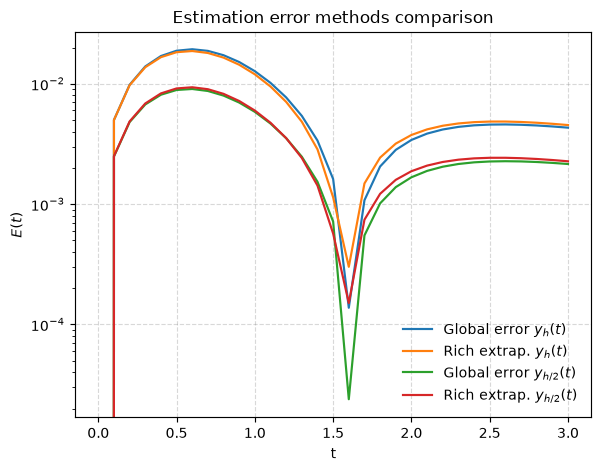

In [12]:
plot2(t, err_est_h, err_est_h2, E_h_Rich) # Plotting comparison

Very good results. Let's solve again the same differential equation with a smaller value for $h$

In [13]:
h = 0.001 # Smaller h

t, y, err_est = euler_forward(f, ft, fy, t0, T, h, y0) # Solution
t, y, err_est

(array([0.   , 0.001, 0.002, ..., 2.998, 2.999, 3.   ], shape=(3001,)),
 array([1.        , 1.        , 0.999999  , ..., 0.18197357, 0.18187429,
        0.18177509], shape=(3001,)),
 array([0.        , 0.0000005 , 0.000001  , ..., 0.00004309, 0.00004309,
        0.00004308], shape=(3001,)))

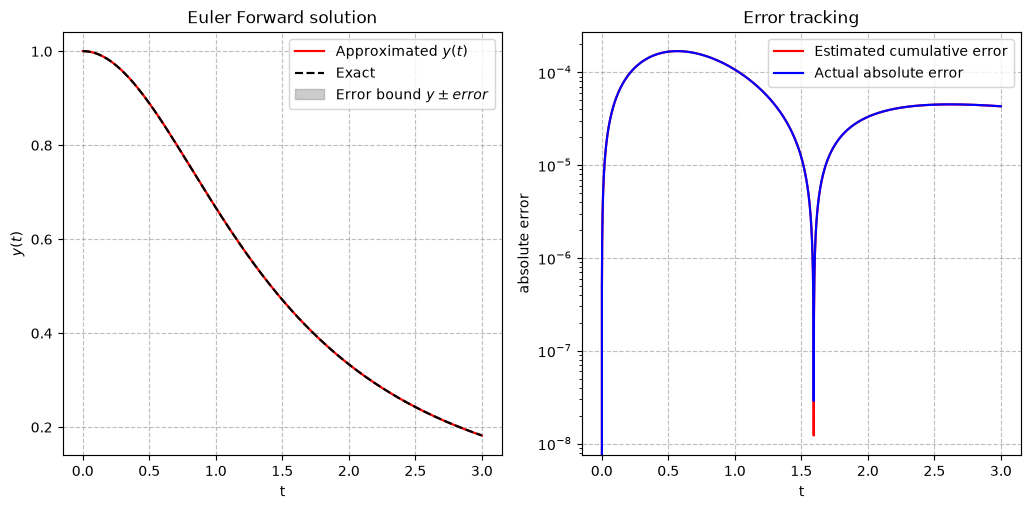

In [14]:
plot(t, y, y_exact, err_est) # Plotting results

In [15]:
# Richardson error checking
_, yh, err_est_h = euler_forward(f, ft, fy, t0, T, h, y0) # Solution for h = 0.001
_, yh2, err_est_h2 = euler_forward(f, ft, fy, t0, T, h / 2.0, y0) # Solution for h = 0.0005

E_h_Rich = 2.0 * np.abs(yh - yh2[::2]) # Richardson error estimation of y_h(t)
err_est_h, E_h_Rich

(array([0.        , 0.0000005 , 0.000001  , ..., 0.00004309, 0.00004309,
        0.00004308], shape=(3001,)),
 array([0.        , 0.0000005 , 0.000001  , ..., 0.00004312, 0.00004311,
        0.0000431 ], shape=(3001,)))

In [16]:
np.max(np.abs(err_est_h - E_h_Rich)) # Maximum difference

np.float64(7.619885893314919e-08)

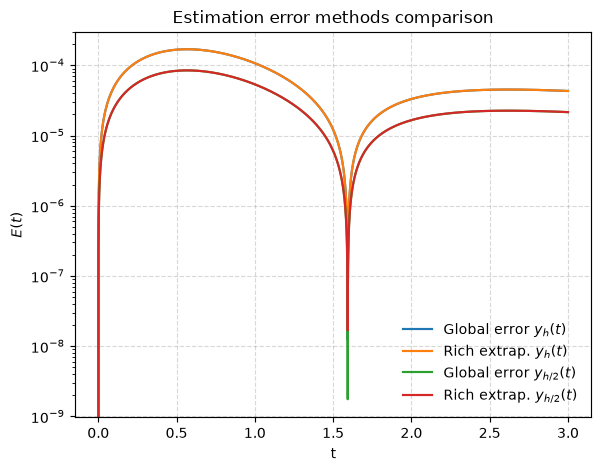

In [17]:
plot2(t, err_est_h, err_est_h2, E_h_Rich) # Plotting comparison

Same results can be obtained using Euler's backward method. In this case, the global error for each step can be computed as:

$$
    E_{i+1} = \frac{E_i + \frac{h ^ 2}{2} \left(\frac{\partial f}{\partial t}(t_{i + 1}, y_{i + 1}) + f(t_{i + 1}, y_{i + 1})\frac{\partial f}{\partial y}(t_{i + 1}, y_{i + 1})\right) + \frac{\epsilon_{\mathrm{mach}}}{2} \left| y_{i+1} \right|}{1 - h \frac{\partial f}{\partial y}(t_{i+1}, y_{i+1})}
$$

The key differences from the Euler's forward formula are:

- The local truncation term has positive sign instead of minus
- The whole expression is divided by the factor $1 - h \frac{\partial f}{\partial y}(t_{i + 1}, y_{i + 1})$ which comes from the implicit nature of the backward Euler step

Python implementation below:

In [18]:
def euler_backward(f, ft, fy, t0, T, h, y0): # Euler's backward method implementation

    u = 2 ** (- 53)  # Roundoff error

    L = T - t0
    subdivs = round(L / h)
    ts = np.linspace(t0, T, subdivs + 1)
    h = L / subdivs

    ys = np.empty(subdivs + 1)
    errs = np.empty(subdivs + 1)

    y = y0
    err = 0.0
    ys[0] = y
    errs[0] = err

    for j in range(subdivs):
        
        t_next = ts[j + 1]
        y_prev = y

        # Backward Euler equation: g(y_next) = y_next - y_prev - h*f(t_next, y_next) = 0
        g = lambda y_next, y_prev, t_next: y_next - y_prev - h * f(t_next, y_next)
        gprime = lambda y_next, y_prev, t_next: 1.0 - h * fy(t_next, y_next)

        y_next = newton( # Newton root-finding by SciPy. It falls back to secant if fprime is None
            func = g,
            x0 = y_prev + h * f(ts[j], y_prev), # Guess: forward step
            args = (y_prev, t_next),
            fprime = gprime,
            tol = 1e-12,
            disp = True)

        # Error propagation for backward Euler:
        ypp = ft(t_next, y_next) + f(t_next, y_next) * fy(t_next, y_next)
        local_trunc = h ** 2 / 2.0 * ypp
        local_round = u * abs(y_next)
        err = (err + local_trunc + local_round) / (1.0 - h * fy(t_next, y_next)) # e_{n + 1} = (e_n + h ^ 2 / 2 * y''(t_{n + 1}) + roundoff) / (1 - h * f_y)

        # Updates
        y = y_next
        ys[j + 1] = y
        errs[j + 1] = err

    return ts, ys, np.abs(errs)

Let's try to average these 2 methods to obtain a better result. Solve:

$$
    y'(t) = \frac{1}{\left[ t \, y(t) \right]^2} \quad y(2) = 1
$$

In [19]:
def f(t, y): return 1.0 / (t * y) ** 2 # f(t, y)
def ft(t, y): return - 2.0 / (t ** 3 * y ** 2) # Derivative of f(t, y) with respect to t
def fy(t, y): return - 2.0 / (t ** 2 * y ** 3) # Derivative of f(t, y) with respect to y
def y_exact(t): return np.cbrt(2.5 - 3.0 / t) # Exact solution function

y0 = 1.0 # y(2)
t0 = 2.0 # Initial t
T = 5.0 # Final t
h = 0.1 # Fixed step size

In [20]:
t, y_fw, err_fw = euler_forward(f, ft, fy, t0, T, h, y0) # Euler's forward solution
_, y_bw, err_bw = euler_backward(f, ft, fy, t0, T, h, y0) # Euler's backward solution

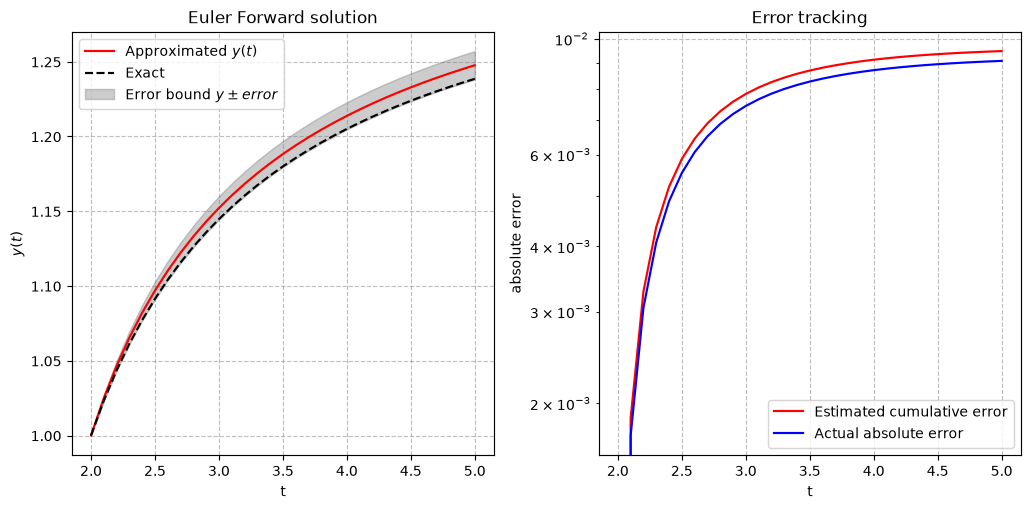

In [21]:
plot(t, y_fw, y_exact, err_fw) # Forward result

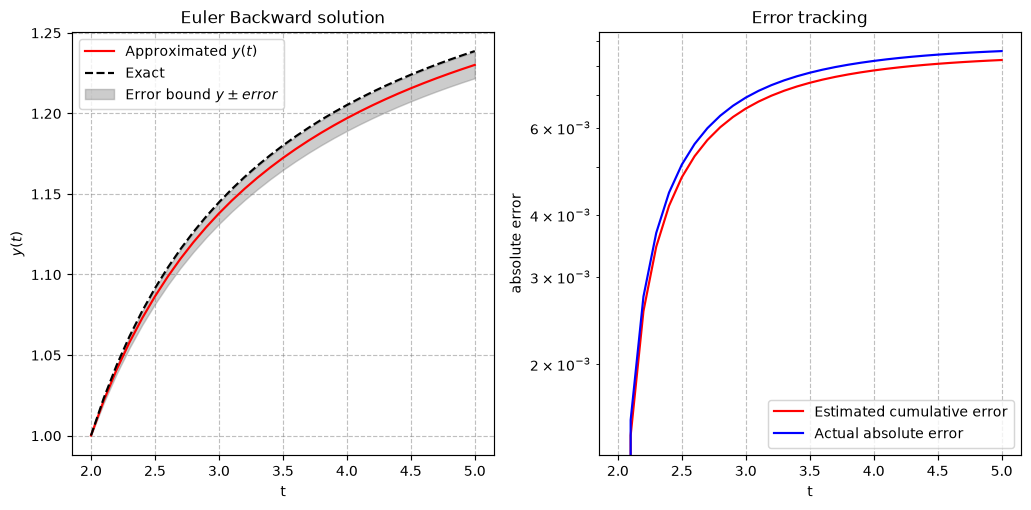

In [22]:
plot(t, y_bw, y_exact, err_bw, title = 'Euler Backward') # Backward result

In [23]:
# Average
y_mid = (y_fw + y_bw) / 2.0
err_mid = (err_fw + err_bw) / 2.0 # Sum of errors

y_mid, err_mid

(array([1.        , 1.02336091, 1.04368907, 1.0615693 , 1.0774383 ,
        1.09163058, 1.10440771, 1.1159778 , 1.12650891, 1.13613846,
        1.14498009, 1.1531287 , 1.16066425, 1.1676546 , 1.17415782,
        1.18022386, 1.18589599, 1.19121185, 1.1962044 , 1.20090259,
        1.20533198, 1.20951522, 1.21347248, 1.21722174, 1.22077911,
        1.22415909, 1.2273747 , 1.23043774, 1.23335889, 1.23614786,
        1.23881346]),
 array([0.        , 0.00165508, 0.00291809, 0.00390485, 0.00469052,
        0.00532592, 0.00584655, 0.00627793, 0.00663881, 0.00694326,
        0.00720199, 0.0074233 , 0.00761371, 0.00777837, 0.00792143,
        0.00804623, 0.00815552, 0.00825155, 0.00833618, 0.00841097,
        0.00847724, 0.00853607, 0.00858841, 0.00863505, 0.00867669,
        0.0087139 , 0.0087472 , 0.00877703, 0.00880376, 0.00882774,
        0.00884926]))

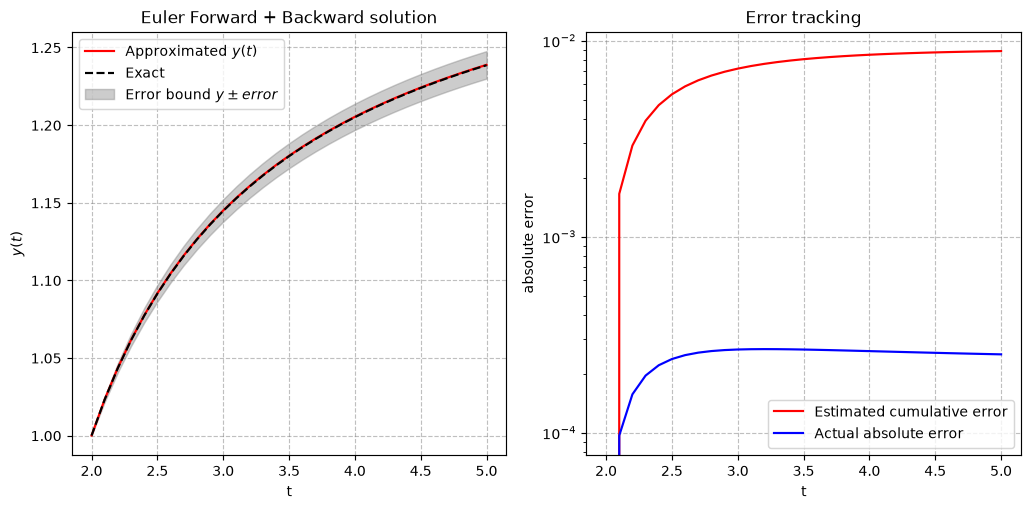

In [24]:
plot(t, y_mid, y_exact, err_mid, title = 'Euler Forward + Backward') # Plotting the result

The solution is more accurate but precision is lower. Let's finally reduce $h$ and increase $T$

In [25]:
h = 0.001 # Smaller h
T = 15.0 # Large T

t, y_fw, err_fw = euler_forward(f, ft, fy, t0, T, h, y0) # Euler's forward solution
_, y_bw, err_bw = euler_backward(f, ft, fy, t0, T, h, y0) # Euler's backward solution

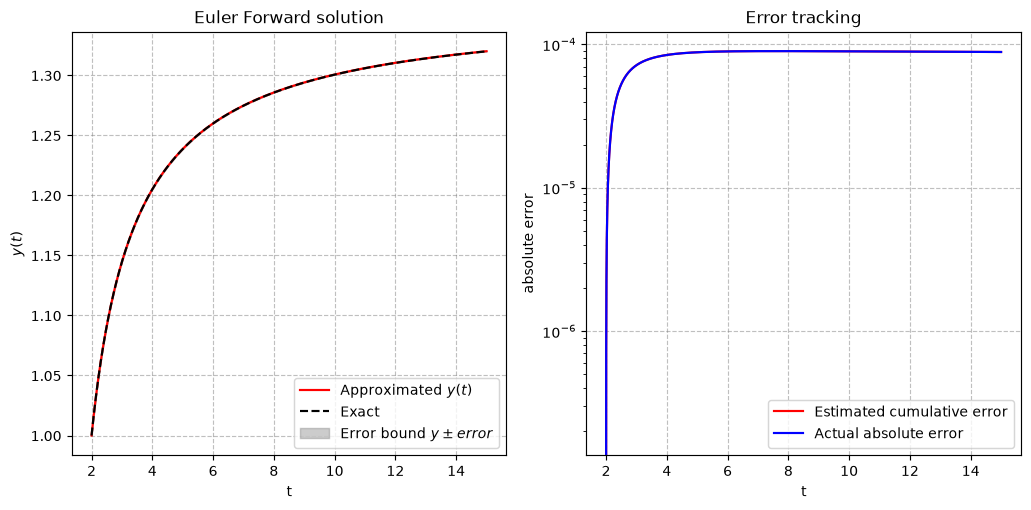

In [26]:
plot(t, y_fw, y_exact, err_fw) # Forward result

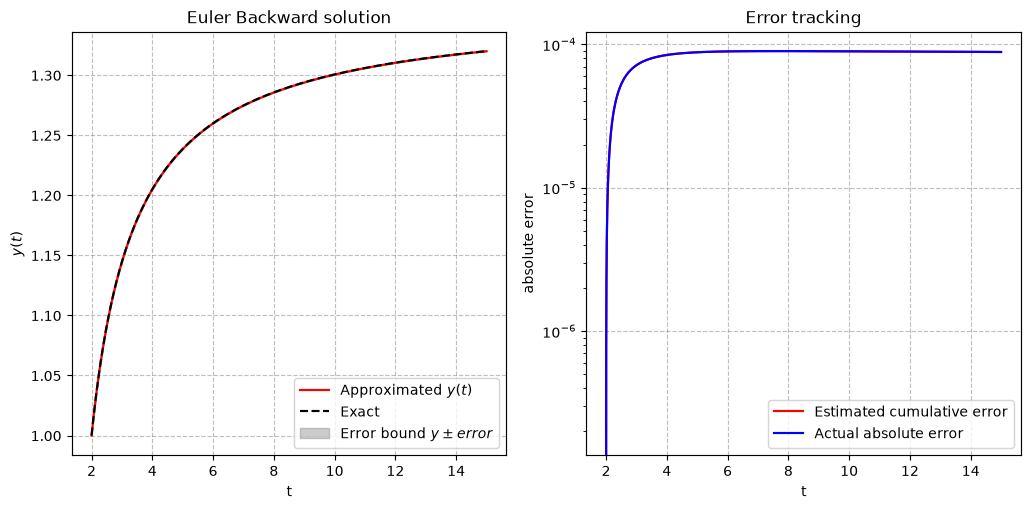

In [27]:
plot(t, y_bw, y_exact, err_bw, title = 'Euler Backward') # Backward result

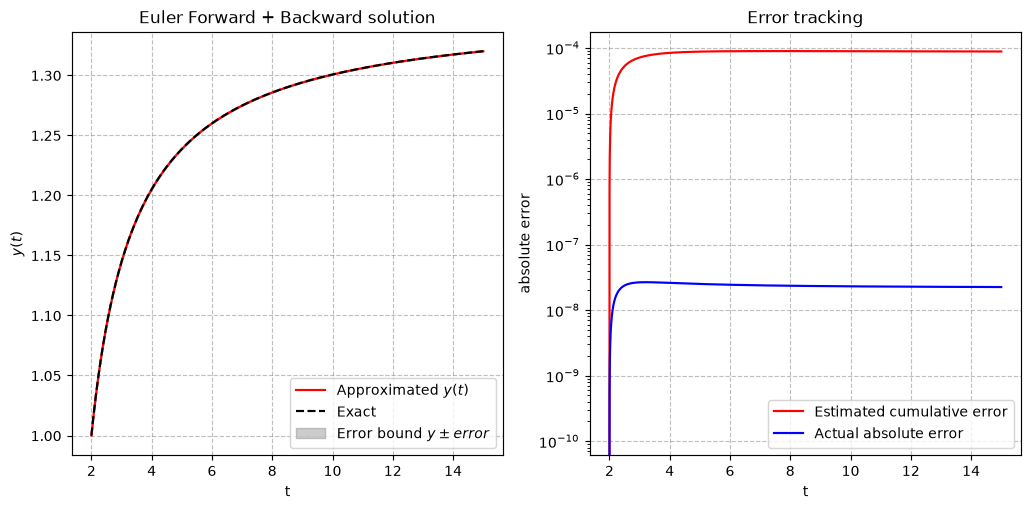

In [28]:
# Average
y_mid = (y_fw + y_bw) / 2.0
err_mid = (err_fw + err_bw) / 2.0

plot(t, y_mid, y_exact, err_mid, title = 'Euler Forward + Backward') # Plotting the result

It's not convenient to average them in this way because global error increases. Crank-Nicolson scheme combines Euler's forward and backward methods to achieve greater accuracy and precision as well